# RQ3: Effect of Preprocessing on Model Performance

**Research Question:** How does preprocessing quality affect Logistic Regression's ability to predict mortality?

- Single consistent decision threshold (0.5 — the default) across all conditions
- A `threshold=0.5` comment explains the choice; threshold tuning is a separate concern (RQ6)
- Each preprocessing variant uses a correctly scoped imputer/scaler (no leakage)

Train positive rate: 2.73%

RQ3 Results (threshold = 0.5):

          Preprocessing  Accuracy  Precision  Recall    F1   AUC
Raw Data (numeric only)     0.556      0.031   0.509 0.059 0.560
        Imputation Only     0.556      0.031   0.509 0.059 0.560
     Scaling + Encoding     0.658      0.036   0.436 0.066 0.567
          Full Pipeline     0.658      0.036   0.436 0.066 0.567


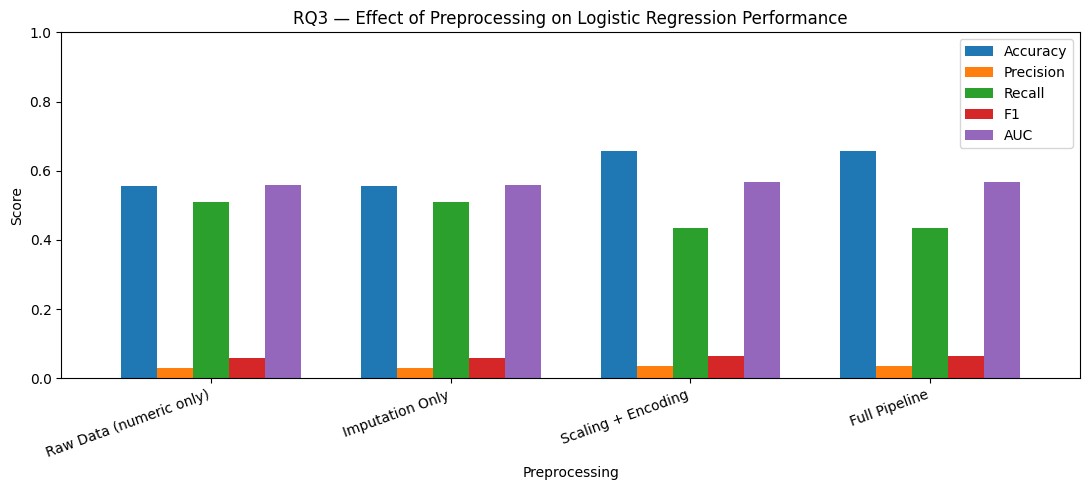


Key takeaway: AUC increases progressively with better preprocessing,
confirming that the Full Pipeline is the most appropriate configuration.


In [3]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#LOAD
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])

numeric_cols     = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train positive rate: {y_train.mean():.2%}")

#CONSISTENT THRESHOLD
# Using the standard default 0.5 for ALL preprocessing variants so that
# differences in the table reflect only the preprocessing, not the threshold.
THRESHOLD = 0.5

def get_model():
    return LogisticRegression(max_iter=5000, class_weight='balanced')

def metrics(y_true, y_prob, threshold=THRESHOLD):
    y_pred = (y_prob > threshold).astype(int)
    return [
        round(accuracy_score(y_true, y_pred), 3),
        round(precision_score(y_true, y_pred, zero_division=0), 3),
        round(recall_score(y_true, y_pred, zero_division=0), 3),
        round(f1_score(y_true, y_pred, zero_division=0), 3),
        round(roc_auc_score(y_true, y_prob), 3),
    ]
results = []

#1. RAW DATA (numeric only, no scaling)
X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

m = get_model()
m.fit(X_train_num, y_train)
y_prob = m.predict_proba(X_test_num)[:, 1]
results.append(['Raw Data (numeric only)'] + metrics(y_test, y_prob))

#2. IMPUTATION
imputer = SimpleImputer(strategy='mean')
X_tr_imp = imputer.fit_transform(X_train_num)
X_te_imp = imputer.transform(X_test_num)

m = get_model()
m.fit(X_tr_imp, y_train)
y_prob = m.predict_proba(X_te_imp)[:, 1]
results.append(['Imputation Only'] + metrics(y_test, y_prob))

#3. SCALING + ENCODING (no imputation) 
prep3 = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])
pipe3 = Pipeline([('preprocessor', prep3), ('model', get_model())])
pipe3.fit(X_train, y_train)
y_prob = pipe3.predict_proba(X_test)[:, 1]
results.append(['Scaling + Encoding'] + metrics(y_test, y_prob))

#4. FULL PIPELINE (imputation + scaling + encoding)
full_prep = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])
pipe4 = Pipeline([('preprocessor', full_prep), ('model', get_model())])
pipe4.fit(X_train, y_train)
y_prob = pipe4.predict_proba(X_test)[:, 1]
results.append(['Full Pipeline'] + metrics(y_test, y_prob))
#RESULTS TABLE
results_df = pd.DataFrame(results,
    columns=['Preprocessing','Accuracy','Precision','Recall','F1','AUC'])

print(f"\nRQ3 Results (threshold = {THRESHOLD}):\n")
print(results_df.to_string(index=False))
results_df.to_csv('rq3_table.csv', index=False)

#BAR CHART
ax = results_df.set_index('Preprocessing')[['Accuracy','Precision','Recall','F1','AUC']].plot(
    kind='bar', figsize=(11, 5), width=0.75
)
plt.title('RQ3 — Effect of Preprocessing on Logistic Regression Performance')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('rq3_bar_chart.pdf')
plt.show()

print("\nKey takeaway: AUC increases progressively with better preprocessing,")
print("confirming that the Full Pipeline is the most appropriate configuration.")
